Starting embeddings/kelsic_esm2_t6_8M_UR50D.csv round 1
Starting embeddings/kelsic_esm2_t6_8M_UR50D.csv round 2
Starting embeddings/kelsic_esm2_t12_35M_UR50D.csv round 1
Starting embeddings/kelsic_esm2_t12_35M_UR50D.csv round 2
Starting embeddings/kelsic_esm2_t30_150M_UR50D.csv round 1
Starting embeddings/kelsic_esm2_t30_150M_UR50D.csv round 2
7
['Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile']
    Rounds        Benchmark                                 Embeddings
0        1         Above WT     embeddings/kelsic_esm2_t6_8M_UR50D.csv
1        1  50th Percentile     embeddings/kelsic_esm2_t6_8M_UR50D.csv
2        4  90th Percent

c:\Users\ese\EsmcBench\backend\src\evolve\evolvetest.py:326: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(convert_to_list)


Plot saved to ../EvolveTest/kelsic\test2/kelsic


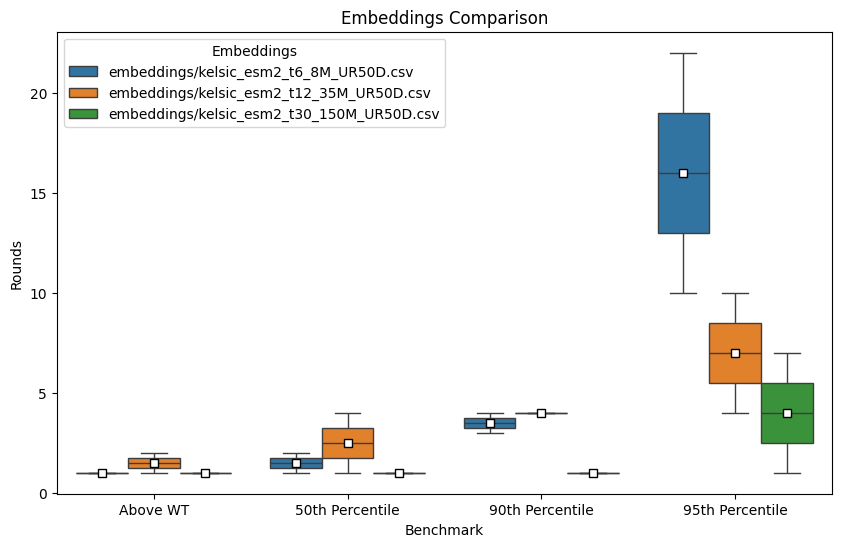

In [ ]:
from evolve.evolvetest import digivolve
from sklearn.ensemble import RandomForestRegressor
from Bio import SeqIO
randomforest = RandomForestRegressor(
        n_estimators=100,
        criterion="friedman_mse",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=1.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=None,
        random_state=1,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None,
    )

prot_name = 'kelsic'
record = SeqIO.read(('../EvolveTest/wt_fasta/'+prot_name+'_WT.fasta'),"fasta")
wt_aa_seq = record.seq

dataset = '50rd_allmodels'
exp_activity_file_path = r'..\EvolveTest\DMS_data\kelsic_dms.xlsx'
embeddings_dir = '../EvolveTest/' + prot_name
embeddings_models = [
    #'esm1b_t33_650M_UR50S',
    #'esm1v_t33_650M_UR90S_1',
    #'esm1v_t33_650M_UR90S_2',
    #'esm1v_t33_650M_UR90S_3',
    #'esm1v_t33_650M_UR90S_4',
    #'esm1v_t33_650M_UR90S_5',
    'esm2_t6_8M_UR50D',
    'esm2_t12_35M_UR50D',
    'esm2_t30_150M_UR50D',
    #'esm2_t33_650M_UR50D',
    #'esmc_600m_WT'
]
embeddings_paths = list(map(lambda x: ('embeddings/'+ prot_name + '_' + x + '.csv'),embeddings_models))
#print(embeddings_paths)
wt_activity = 1
benchmarks = {
    'Above WT' : wt_activity,
    '50th Percentile' : 0.5,
    '90th Percentile' : 0.9,
    '95th Percentile' : 0.95,
}
model_type = randomforest
rounds_evo = 50
num_var = 16


evolve_df = digivolve(wt_aa_seq,prot_name,wt_activity,benchmarks,dataset,exp_activity_file_path,embeddings_dir, embeddings_paths,num_var,rounds_evo,model_type)

c:\Users\ese\EsmcBench\backend\src\evolve\evolvetest.py:326: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(convert_to_list)


['Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '90th Percentile', '95th Percentile', 'Above WT', '50th Percentile', '9

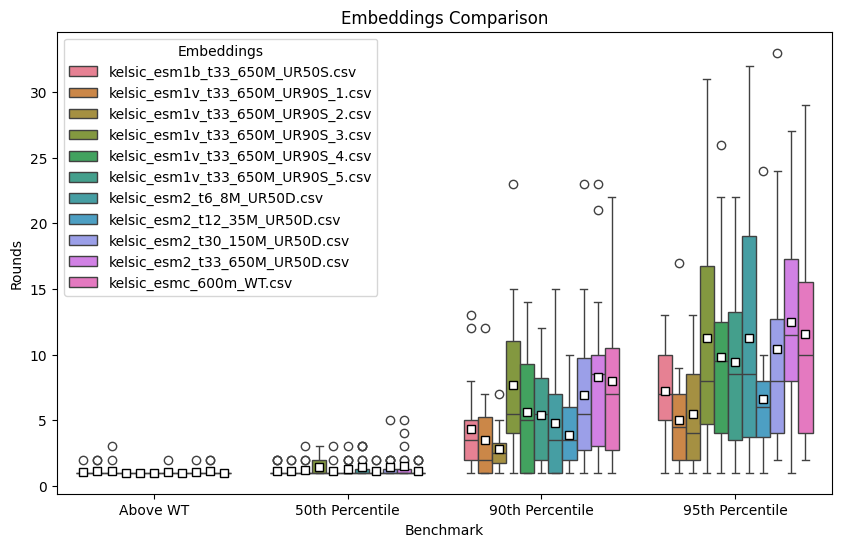

In [3]:
from evolve.evolvetest import plot_evolution_boxplot
import pandas as pd
evolve_df = pd.read_excel(r'..\EvolveTest\kelsic\20rd_allmodels\raw_16_20rd_allmodels_Model_Comparisons_291950.xlsx')
plot_evolution_boxplot(evolve_df, benchmarks)